# StormEngine — HadISD × ERA5: Full Data Aggregation & Analysis Pipeline

Complete four-step pipeline for the HadISD–ERA5 data aggregation chapter:

| Step | Content |
|---|---|
| **1** | Cross-temporal alignment — co-location table ERA5 × HadISD |
| **2** | Seasonal bias analysis — ERA5 vs real observations |
| **3** | HadISD data quality — missing rate, outliers, temporal consistency |
| **4** | Coverage assessment — spatial distribution & variable availability |

## Input files
| File | Content |
|---|---|
| `final_2024_11_msl.csv` | ERA5 MSL grid — November 2024 |
| `final_2024_12_msl.csv` | ERA5 MSL grid — December 2024 |
| `final_2024_1_msl.csv` | ERA5 MSL grid — January 2025 |
| `final_2024_2_msl.csv` | ERA5 MSL grid — February 2025 |
| `HadISD_Adriatic/*.csv` | HadISD point observations — same period |

## 0. Imports and Configuration

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats as sps
import glob, os, json, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 200, 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'legend.frameon': False,
})

# ── ERA5 monthly files ──────────────────────────────────────────────────────
ERA5_FILES = {
    'November' : {'path': 'final_2024_11_msl.csv', 'year': 2024, 'month': 11},
    'December' : {'path': 'final_2024_12_msl.csv', 'year': 2024, 'month': 12},
    'January'  : {'path': 'final_2024_1_msl.csv',  'year': 2025, 'month':  1},
    'February' : {'path': 'final_2024_2_msl.csv',  'year': 2025, 'month':  2},
}

# ── HadISD ──────────────────────────────────────────────────────────────────
HADISD_DIR  = 'hadisd_adriatic_2024.csv'   # file nella stessa cartella del notebook
HADISD_VAR  = 'PRESS'

# ── Domain ──────────────────────────────────────────────────────────────────
LAT_MIN, LAT_MAX = 39.0, 46.5
LON_MIN, LON_MAX = 12.0, 20.0
PA_TO_HPA        = 1.0 / 100.0

# ── Thresholds ───────────────────────────────────────────────────────────────
ALIGN_TOL_MIN   = 30
PHYS_MIN        = 950.0
PHYS_MAX        = 1060.0
MISSING_MAX_PCT = 30.0
JUMP_THRESHOLD  = 10.0

SEASON_MAP    = {11:'Autumn', 12:'Winter', 1:'Winter', 2:'Winter'}
MONTH_COLORS  = {'November':'#fb8d3d','December':'#08519c',
                 'January':'#2c7fb8','February':'#41b6c4'}
SEASON_COLORS = {'Winter':'#08519c','Autumn':'#fb8d3d'}

# ── Verify all files exist before running ────────────────────────────────────
print('Working directory:', os.getcwd())
print()
all_ok = True
for name, meta in ERA5_FILES.items():
    exists = os.path.isfile(meta['path'])
    print(f'  {"OK" if exists else "MISSING":6s} {meta["path"]}')
    if not exists: all_ok = False
exists_h = os.path.isfile(HADISD_DIR)
print(f'  {"OK" if exists_h else "MISSING":6s} {HADISD_DIR}')
if not exists_h: all_ok = False
print()
print('All files found.' if all_ok else 'FIX THE MISSING FILES ABOVE BEFORE CONTINUING.')

Working directory: d:\StormEngine\DataAggregation\HadISD

  OK     final_2024_11_msl.csv
  OK     final_2024_12_msl.csv
  OK     final_2024_1_msl.csv
  OK     final_2024_2_msl.csv
  OK     hadisd_adriatic_2024.csv

All files found.


---
# STEP 1 — Cross-Temporal Alignment

Aligns HadISD point observations with ERA5 hourly gridded fields on the same timestamp (±30 min tolerance),
extracts ERA5 values at station coordinates via **bilinear interpolation**, and builds the
co-location table `(station_id, timestamp, hadisd_msl, era5_msl, bias)`.

## 1.1 Load ERA5 — Build Hourly Gridded Dictionary

In [3]:
def load_era5_month(path, year, month):
    df = pd.read_csv(path)
    sc = [c for c in df.columns if c.startswith('SAMPLE_')]
    base = pd.Timestamp(year=year, month=month, day=1, hour=0, tz='UTC')
    timestamps = [base + pd.Timedelta(hours=i) for i in range(len(sc))]
    samples = df[sc].values * PA_TO_HPA
    valid = ~np.all(np.isnan(samples), axis=0)
    samples = samples[:, valid]
    timestamps = [t for t, v in zip(timestamps, valid) if v]
    return {
        'timestamps': timestamps,
        'samples'   : samples,
        'lon'       : df['lon'].values,
        'lat'       : df['lat'].values,
        'lons_uniq' : np.sort(df['lon'].unique()),
        'lats_uniq' : np.sort(df['lat'].unique()),
    }

era5 = {}
for month_name, meta in ERA5_FILES.items():
    try:
        d = load_era5_month(meta['path'], meta['year'], meta['month'])
        era5[month_name] = d
        print(f'{month_name:9s} | {d["timestamps"][0]} → {d["timestamps"][-1]} '
              f'| {len(d["timestamps"])} hours | {d["samples"].shape[0]} pts')
    except FileNotFoundError:
        print(f'{month_name}: NOT FOUND — {meta["path"]}')

November  | 2024-11-01 00:00:00+00:00 → 2024-11-30 23:00:00+00:00 | 720 hours | 1024 pts
December  | 2024-12-01 00:00:00+00:00 → 2024-12-31 23:00:00+00:00 | 744 hours | 1023 pts
January   | 2025-01-01 00:00:00+00:00 → 2025-01-31 23:00:00+00:00 | 744 hours | 1023 pts
February  | 2025-02-01 00:00:00+00:00 → 2025-03-03 23:00:00+00:00 | 744 hours | 1023 pts


## 1.2 Load HadISD Observations

In [4]:
def load_hadisd(path_or_folder, var_code='PRESS'):
    if os.path.isfile(path_or_folder):
        files = [path_or_folder]
    else:
        files = sorted(glob.glob(os.path.join(path_or_folder, '*.csv')))
    if not files:
        raise FileNotFoundError(f'No CSV files found at: {path_or_folder}')

    dfs = []
    for f in files:
        try: dfs.append(pd.read_csv(f))
        except Exception as e: print(f'  Warning: {f}: {e}')
    df = pd.concat(dfs, ignore_index=True)

    if 'sensor_code' in df.columns:
        df = df[df['sensor_code'] == var_code].copy()
    df['dt'] = pd.to_datetime(df['dt'], utc=True)
    df = df[['station_id','dt','value','lat','lon']].dropna()
    df = df[df['lat'].between(LAT_MIN,LAT_MAX) & df['lon'].between(LON_MIN,LON_MAX)].copy()
    df['month_num']  = df['dt'].dt.month
    df['month_name'] = df['month_num'].map({11:'November',12:'December',1:'January',2:'February'})
    df['season']     = df['month_num'].map(SEASON_MAP)
    return df.sort_values('dt').reset_index(drop=True)

hadisd = load_hadisd(HADISD_DIR, var_code=HADISD_VAR)
print(f'HadISD obs      : {len(hadisd)}')
print(f'Unique stations : {hadisd["station_id"].nunique()}')
print(f'Date range      : {hadisd["dt"].min()} → {hadisd["dt"].max()}')
print(f'Value range     : {hadisd["value"].min():.1f} — {hadisd["value"].max():.1f} hPa')
print(hadisd.groupby('month_name')[['station_id']].count().rename(columns={'station_id':'n_obs'}))

HadISD obs      : 655285
Unique stations : 128
Date range      : 2024-01-01 00:00:00+00:00 → 2024-12-31 00:00:00+00:00
Value range     : 723.1 — 1038.5 hPa
            n_obs
month_name       
December    51281
February    56854
January     61164
November    48338


## 1.3 Bilinear Interpolation + Co-location Table

In [5]:
def bilinear_interp(grid, lats, lons, qlat, qlon):
    qlat = np.clip(qlat, lats[0], lats[-1])
    qlon = np.clip(qlon, lons[0], lons[-1])
    i1 = np.clip(np.searchsorted(lats, qlat)-1, 0, len(lats)-2)
    j1 = np.clip(np.searchsorted(lons, qlon)-1, 0, len(lons)-2)
    i2, j2 = i1+1, j1+1
    lf = (qlat-lats[i1])/(lats[i2]-lats[i1]+1e-10)
    cf = (qlon-lons[j1])/(lons[j2]-lons[j1]+1e-10)
    return float(grid[i1,j1]*(1-lf)*(1-cf) + grid[i2,j1]*lf*(1-cf)
                +grid[i1,j2]*(1-lf)*cf     + grid[i2,j2]*lf*cf)

def reshape_grid(vals, lon, lat, lats_u, lons_u):
    g = np.full((len(lats_u), len(lons_u)), np.nan)
    li = {v:i for i,v in enumerate(lons_u)}
    la = {v:i for i,v in enumerate(lats_u)}
    for v,lo,lt in zip(vals,lon,lat):
        if not (np.isnan(lo) or np.isnan(lt)): g[la[lt],li[lo]] = v
    return g

def build_colocation(hadisd_df, era5_dict, tol_min=30):
    tol = pd.Timedelta(minutes=tol_min)
    rows, n_unmatched = [], 0
    for month_name, d in era5_dict.items():
        era5_times = pd.DatetimeIndex(d['timestamps'])
        sub = hadisd_df[hadisd_df['month_name']==month_name].copy()
        if len(sub)==0: print(f'  {month_name}: no HadISD obs'); continue
        print(f'  {month_name}: {len(sub)} obs → matching...')
        grids = {ts: reshape_grid(d['samples'][:,h], d['lon'], d['lat'],
                                  d['lats_uniq'], d['lons_uniq'])
                 for h, ts in enumerate(d['timestamps'])}
        for _, row in sub.iterrows():
            deltas = np.abs(era5_times - row['dt'])
            mi = deltas.argmin()
            if deltas[mi] > tol: n_unmatched+=1; continue
            era5_val = bilinear_interp(grids[d['timestamps'][mi]],
                                       d['lats_uniq'], d['lons_uniq'],
                                       row['lat'], row['lon'])
            rows.append({'station_id':row['station_id'],'dt':row['dt'],
                         'era5_dt':d['timestamps'][mi],
                         'dt_diff_min':deltas[mi].total_seconds()/60,
                         'lat':row['lat'],'lon':row['lon'],
                         'month_name':month_name,'season':row['season'],
                         'hadisd_msl':row['value'],'era5_msl':era5_val,
                         'bias':row['value']-era5_val})
    coloc = pd.DataFrame(rows)
    print(f'\nMatched: {len(coloc)} | Unmatched: {n_unmatched}')
    return coloc

print('Building co-location table...')
coloc = build_colocation(hadisd, era5, tol_min=ALIGN_TOL_MIN)
coloc.to_csv('colocation_era5_hadisd_msl.csv', index=False)
print(f'Saved -> colocation_era5_hadisd_msl.csv')
coloc.tail()

Building co-location table...
  November: 48338 obs → matching...
  December: 51281 obs → matching...
  January: 61164 obs → matching...
  February: 56854 obs → matching...

Matched: 99619 | Unmatched: 118018
Saved -> colocation_era5_hadisd_msl.csv


,station_id,dt,era5_dt,dt_diff_min,lat,lon,month_name,season,hadisd_msl,era5_msl,bias
99614,HADISD_144450-99999,2024-12-31 00:00:00+00:00,2024-12-31 00:00:00+00:00,0.0,43.517,16.433,December,Winter,1014.2,1030.665892,-16.465892
99615,HADISD_144440-99999,2024-12-31 00:00:00+00:00,2024-12-31 00:00:00+00:00,0.0,43.539,16.298,December,Winter,1028.0,1030.629250,-2.629250
99616,HADISD_141050-99999,2024-12-31 00:00:00+00:00,2024-12-31 00:00:00+00:00,0.0,45.473,13.615,December,Winter,1030.4,1030.502170,-0.102170
99617,HADISD_145570-99999,2024-12-31 00:00:00+00:00,2024-12-31 00:00:00+00:00,0.0,44.550,18.700,December,Winter,995.2,1032.237825,-37.037825
99618,HADISD_166410-99999,2024-12-31 00:00:00+00:00,2024-12-31 00:00:00+00:00,0.0,39.602,19.912,December,Winter,1029.0,1030.283982,-1.283982


## 1.4 Alignment QC + Scatter Plot

Total matched     : 99619
Unique stations   : 123
ERA5 range (hPa)  : 989.6 — 1038.8
HadISD range (hPa): 723.1 — 1036.4
NaN in era5_msl   : 48338


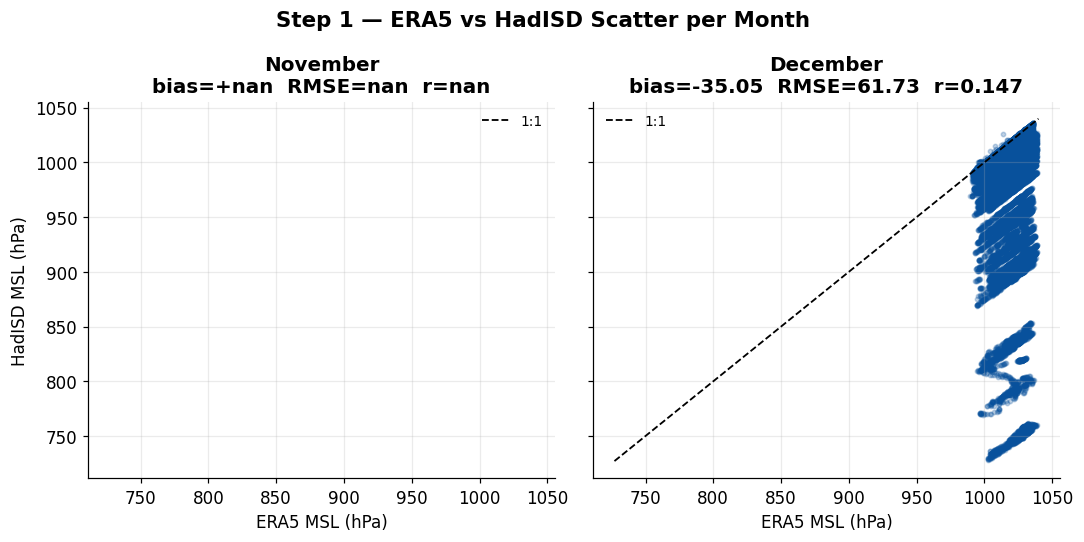

In [5]:
print(f'Total matched     : {len(coloc)}')
print(f'Unique stations   : {coloc["station_id"].nunique()}')
print(f'ERA5 range (hPa)  : {coloc["era5_msl"].min():.1f} — {coloc["era5_msl"].max():.1f}')
print(f'HadISD range (hPa): {coloc["hadisd_msl"].min():.1f} — {coloc["hadisd_msl"].max():.1f}')
print(f'NaN in era5_msl   : {coloc["era5_msl"].isna().sum()}')

months_p = [m for m in ['November','December','January','February']
            if m in coloc['month_name'].values]
n = len(months_p)
fig, axes = plt.subplots(1, n, figsize=(5*n, 5), sharey=True, sharex=True)
if n==1: axes=[axes]
for ax, month in zip(axes, months_p):
    sub = coloc[coloc['month_name']==month]
    ax.scatter(sub['era5_msl'], sub['hadisd_msl'],
               alpha=0.25, s=8, color=MONTH_COLORS[month])
    lims=[min(sub['era5_msl'].min(),sub['hadisd_msl'].min())-1,
          max(sub['era5_msl'].max(),sub['hadisd_msl'].max())+1]
    ax.plot(lims,lims,'k--',linewidth=1.2,label='1:1')
    bias = (sub['hadisd_msl']-sub['era5_msl']).mean()
    rmse = np.sqrt(((sub['hadisd_msl']-sub['era5_msl'])**2).mean())
    r    = sub[['era5_msl','hadisd_msl']].corr().iloc[0,1]
    ax.set_title(f'{month}\nbias={bias:+.2f}  RMSE={rmse:.2f}  r={r:.3f}')
    ax.set_xlabel('ERA5 MSL (hPa)'); ax.legend(fontsize=9)
axes[0].set_ylabel('HadISD MSL (hPa)')
fig.suptitle('Step 1 — ERA5 vs HadISD Scatter per Month', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('s1_scatter.png', bbox_inches='tight'); plt.show()

---
# STEP 2 — Seasonal Bias Analysis

Quantifies the systematic discrepancy between ERA5 and real HadISD observations,
stratified by month and season. This is the methodological core of the Data Aggregation chapter.

## 2.1 Bias Statistics per Month and Season

In [6]:
print('Bias summary (hPa) — HadISD minus ERA5:')
bias_stats = coloc.groupby('month_name')['bias'].agg(
    mean='mean', std='std', median='median',
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75),
    n='count'
).round(3)
print(bias_stats.to_string())

print('\nSeasonal bias:')
print(coloc.groupby('season')['bias'].agg(
    mean='mean', std='std', median='median', n='count'
).round(3).to_string())

Bias summary (hPa) — HadISD minus ERA5:
              mean     std  median    q25    q75      n
month_name                                             
December   -35.049  50.821 -16.344 -36.64 -6.431  51281
November       NaN     NaN     NaN    NaN    NaN      0

Seasonal bias:
          mean     std  median      n
season                               
Autumn     NaN     NaN     NaN      0
Winter -35.049  50.821 -16.344  51281


## 2.2 Boxplot Bias per Month and Season

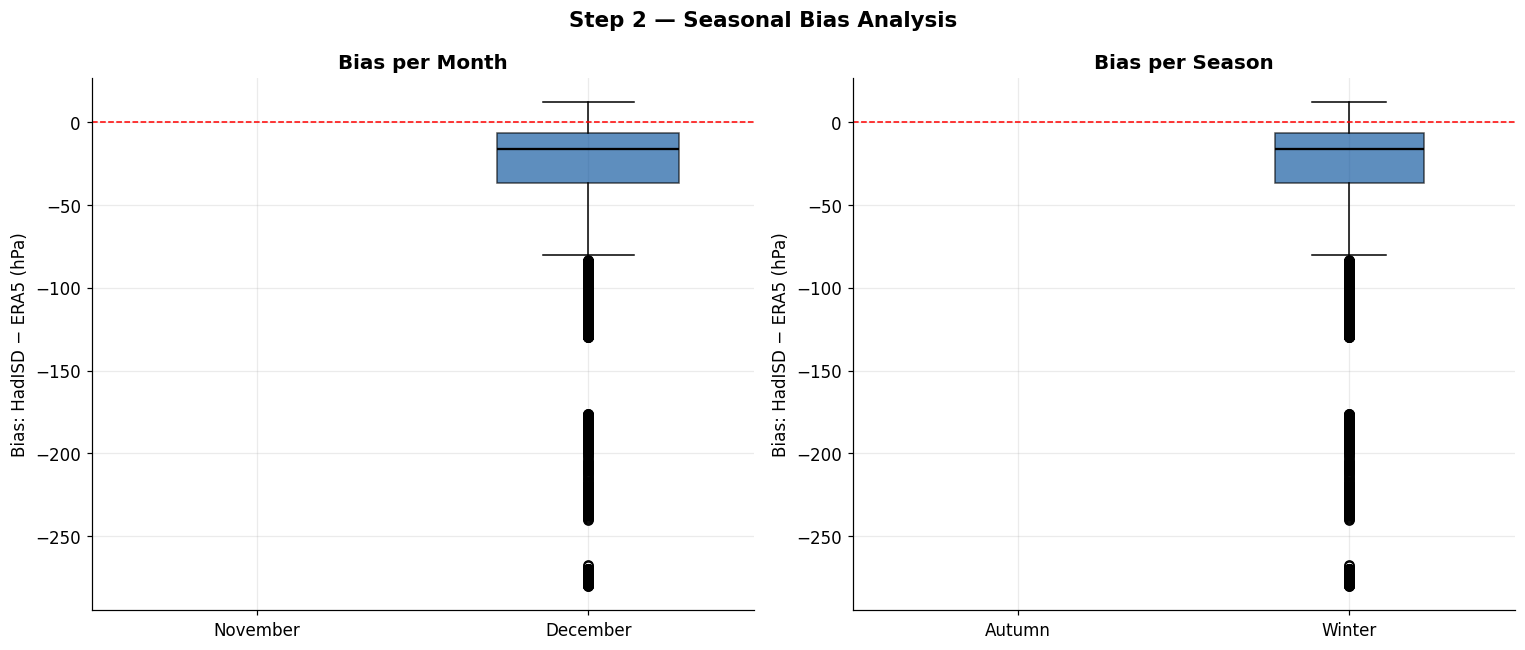

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
month_order = [m for m in ['November','December','January','February']
               if m in coloc['month_name'].values]
bp1 = ax1.boxplot([coloc[coloc['month_name']==m]['bias'].values for m in month_order],
                  patch_artist=True, widths=0.55,
                  medianprops=dict(color='black',linewidth=1.5))
for patch, m in zip(bp1['boxes'], month_order):
    patch.set_facecolor(MONTH_COLORS[m]); patch.set_alpha(0.65)
ax1.axhline(0,color='red',linestyle='--',linewidth=1)
ax1.set_xticks(range(1,len(month_order)+1)); ax1.set_xticklabels(month_order)
ax1.set_ylabel('Bias: HadISD − ERA5 (hPa)'); ax1.set_title('Bias per Month')

seasons = sorted(coloc['season'].unique())
bp2 = ax2.boxplot([coloc[coloc['season']==s]['bias'].values for s in seasons],
                  patch_artist=True, widths=0.45,
                  medianprops=dict(color='black',linewidth=1.5))
for patch, s in zip(bp2['boxes'], seasons):
    patch.set_facecolor(SEASON_COLORS.get(s,'gray')); patch.set_alpha(0.65)
ax2.axhline(0,color='red',linestyle='--',linewidth=1)
ax2.set_xticks(range(1,len(seasons)+1)); ax2.set_xticklabels(seasons)
ax2.set_ylabel('Bias: HadISD − ERA5 (hPa)'); ax2.set_title('Bias per Season')
fig.suptitle('Step 2 — Seasonal Bias Analysis', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('s2_bias_boxplot.png', bbox_inches='tight'); plt.show()

## 2.3 Spatial Bias Map

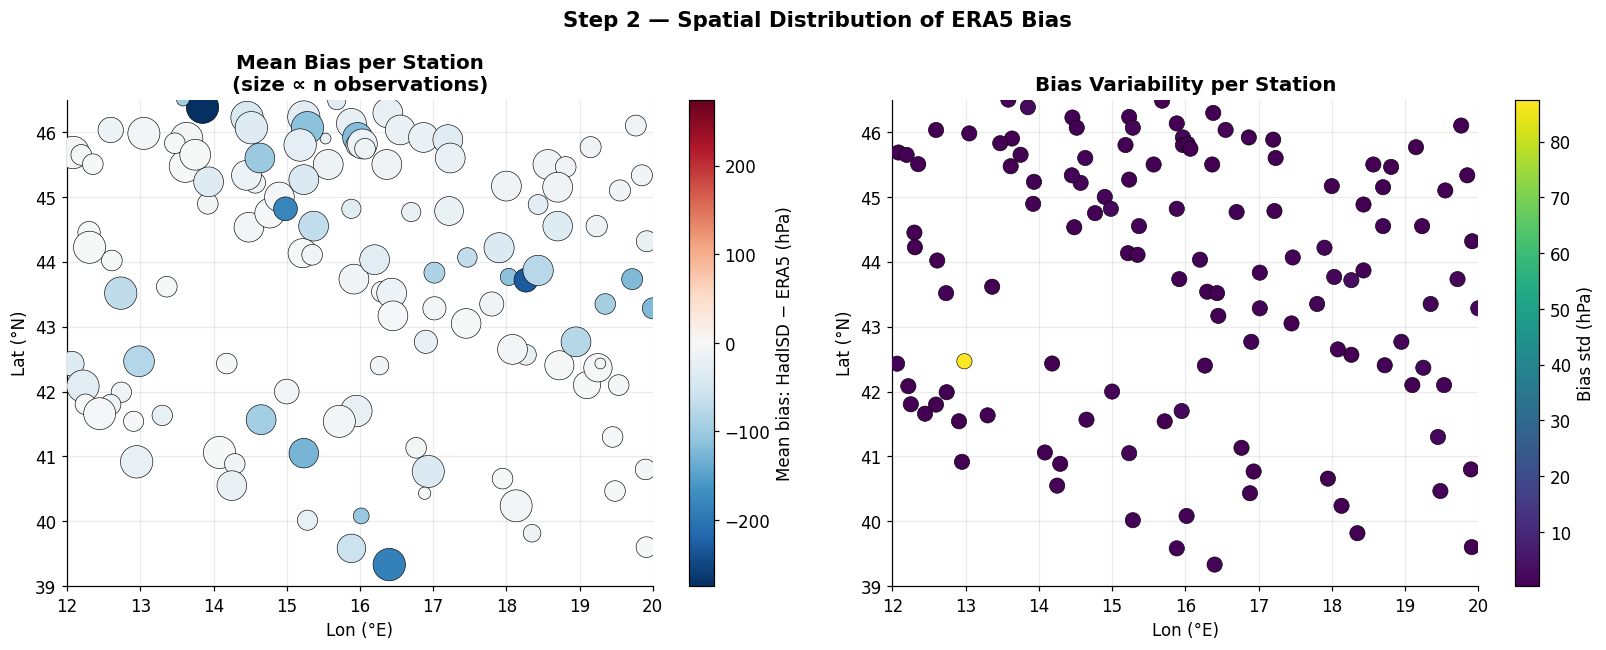

Top 5 most biased stations:
         station_id    lat    lon  mean_bias  n_obs
HADISD_161460-99999 44.450 12.300  -0.128916    282
HADISD_161050-99999 45.505 12.352  -0.376120    229
HADISD_144620-99999 43.050 17.450  -0.475593    562
HADISD_141050-99999 45.473 13.615  -0.502291    678
HADISD_161480-99999 44.224 12.307  -0.514977    673


In [8]:
station_bias = coloc.groupby(['station_id','lat','lon'])['bias'].agg(
    mean_bias='mean', std_bias='std', n_obs='count'
).reset_index()

vmax = station_bias['mean_bias'].abs().max()
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
sc1 = ax1.scatter(station_bias['lon'], station_bias['lat'],
                  c=station_bias['mean_bias'], cmap='RdBu_r', norm=norm,
                  s=station_bias['n_obs']/station_bias['n_obs'].max()*400+50,
                  edgecolors='black', linewidths=0.4, zorder=5)
plt.colorbar(sc1, ax=ax1, label='Mean bias: HadISD − ERA5 (hPa)')
ax1.set(xlim=(LON_MIN,LON_MAX), ylim=(LAT_MIN,LAT_MAX),
        xlabel='Lon (°E)', ylabel='Lat (°N)',
        title='Mean Bias per Station\n(size ∝ n observations)')

sc2 = ax2.scatter(station_bias['lon'], station_bias['lat'],
                  c=station_bias['std_bias'], cmap='viridis',
                  s=100, edgecolors='black', linewidths=0.4, zorder=5)
plt.colorbar(sc2, ax=ax2, label='Bias std (hPa)')
ax2.set(xlim=(LON_MIN,LON_MAX), ylim=(LAT_MIN,LAT_MAX),
        xlabel='Lon (°E)', ylabel='Lat (°N)', title='Bias Variability per Station')
fig.suptitle('Step 2 — Spatial Distribution of ERA5 Bias', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('s2_spatial_bias.png', bbox_inches='tight'); plt.show()

print('Top 5 most biased stations:')
print(station_bias.nlargest(5,'mean_bias')[['station_id','lat','lon','mean_bias','n_obs']].to_string(index=False))

## 2.4 Seasonal Bias per Station — Heatmap

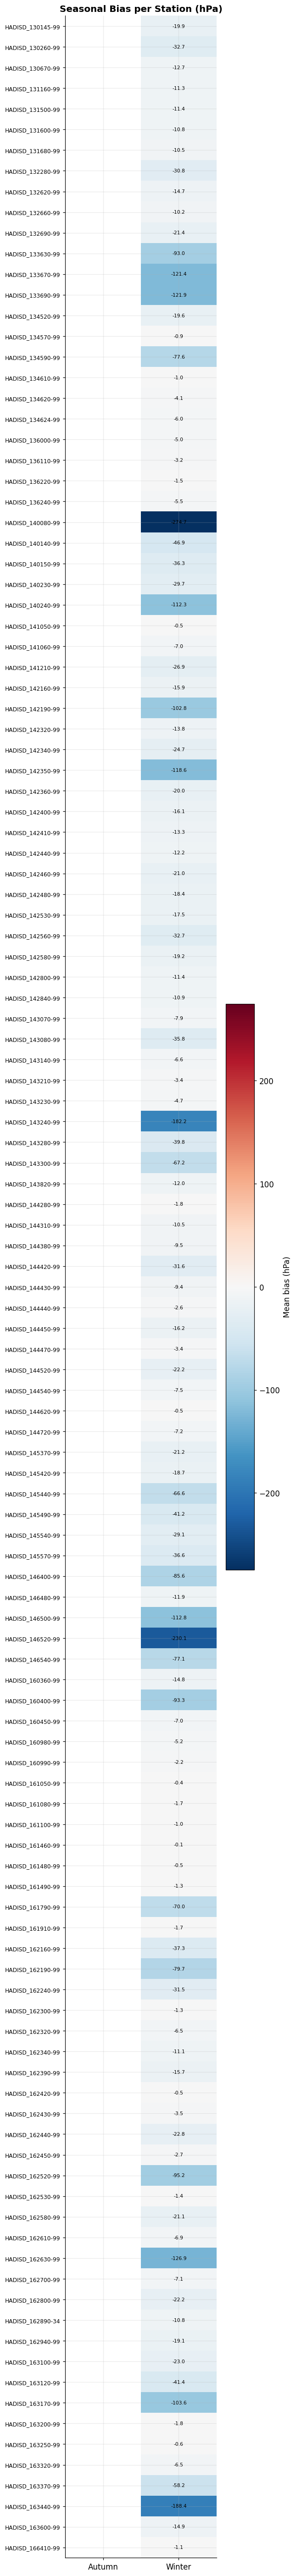

In [9]:
pivot = coloc.groupby(['station_id','season'])['bias'].mean().unstack(fill_value=np.nan)
if len(pivot) > 1:
    fig, ax = plt.subplots(figsize=(max(6,len(pivot.columns)*2+2), max(4,len(pivot)*0.4+2)))
    im = ax.imshow(pivot.values, cmap='RdBu_r', aspect='auto',
                   vmin=-pivot.abs().max().max(), vmax=pivot.abs().max().max())
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([s[:16] for s in pivot.index], fontsize=8)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            v = pivot.values[i,j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=7)
    plt.colorbar(im, ax=ax, label='Mean bias (hPa)')
    ax.set_title('Seasonal Bias per Station (hPa)')
    plt.tight_layout(); plt.savefig('s2_bias_heatmap.png', bbox_inches='tight'); plt.show()
else:
    print('Not enough stations for heatmap — run with more stations.')

---
# STEP 3 — HadISD Data Quality

Although HadISD includes internal QC flags, an independent check is applied covering:
missing rate per station, physical plausibility, and temporal consistency (jump detection).
Stations exceeding quality thresholds are flagged for exclusion.

## 3.1 Missing Rate per Station

Expected hours in period: 2880

Stations total          : 128
Stations flagged (>30.0% missing): 6

Missing rate distribution:
count    128.0
mean       5.4
std       17.1
min        0.0
25%        0.0
50%        0.0
75%        3.4
max       99.5


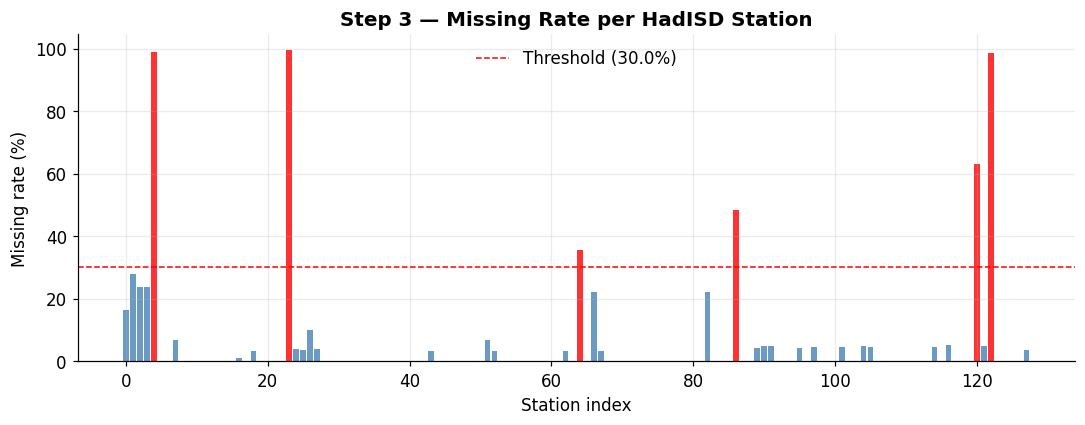

In [10]:
# Expected observations: one per hour over the 4 months
import calendar
total_hours = sum(
    calendar.monthrange(meta['year'], meta['month'])[1] * 24
    for meta in ERA5_FILES.values()
)
print(f'Expected hours in period: {total_hours}')

obs_per_station = hadisd.groupby('station_id').size().rename('n_obs')
missing_rate    = (1 - obs_per_station / total_hours) * 100
missing_rate    = missing_rate.clip(lower=0).rename('missing_pct')

station_qc = pd.DataFrame({'n_obs': obs_per_station, 'missing_pct': missing_rate})
station_qc['flagged_missing'] = station_qc['missing_pct'] > MISSING_MAX_PCT

print(f'\nStations total          : {len(station_qc)}')
print(f'Stations flagged (>{MISSING_MAX_PCT}% missing): {station_qc["flagged_missing"].sum()}')
print('\nMissing rate distribution:')
print(station_qc['missing_pct'].describe().round(1).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['red' if f else 'steelblue' for f in station_qc['flagged_missing']]
ax.bar(range(len(station_qc)), station_qc['missing_pct'].values, color=colors, alpha=0.8)
ax.axhline(MISSING_MAX_PCT, color='red', linestyle='--', linewidth=1,
           label=f'Threshold ({MISSING_MAX_PCT}%)')
ax.set(xlabel='Station index', ylabel='Missing rate (%)',
       title='Step 3 — Missing Rate per HadISD Station')
ax.legend()
plt.tight_layout(); plt.savefig('s3_missing_rate.png', bbox_inches='tight'); plt.show()

## 3.2 Physical Plausibility Check

Physically implausible values (outside [950.0,1060.0] hPa): 110275
         station_id                        dt  value
HADISD_140240-99999 2024-01-01 00:00:00+00:00  899.8
HADISD_146520-99999 2024-01-01 00:00:00+00:00  788.8
HADISD_146540-99999 2024-01-01 00:00:00+00:00  940.2
HADISD_140080-99999 2024-01-01 00:00:00+00:00  739.2
HADISD_163440-99999 2024-01-01 00:00:00+00:00  832.4
HADISD_133670-99999 2024-01-01 00:00:00+00:00  897.1
HADISD_133690-99999 2024-01-01 00:00:00+00:00  897.2
HADISD_134590-99999 2024-01-01 00:00:00+00:00  942.9
HADISD_143300-99999 2024-01-01 00:00:00+00:00  945.9
HADISD_142350-99999 2024-01-01 00:00:00+00:00  895.0
Z-score > 4 outliers (per-station): 196
         station_id                        dt  value   z_score
HADISD_163440-99999 2024-01-06 22:00:00+00:00  810.5  4.009293
HADISD_163440-99999 2024-01-07 01:00:00+00:00  810.5  4.009293
HADISD_163440-99999 2024-01-07 02:00:00+00:00  810.4  4.026883
HADISD_163440-99999 2024-01-07 03:00:00+00:00  809.9  4.11

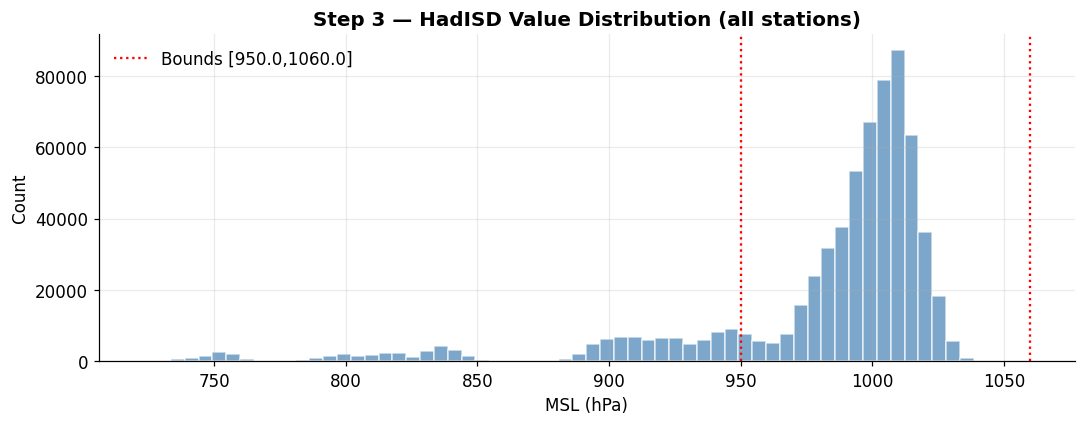

In [11]:
phys_bad = hadisd[(hadisd['value'] < PHYS_MIN) | (hadisd['value'] > PHYS_MAX)]
print(f'Physically implausible values (outside [{PHYS_MIN},{PHYS_MAX}] hPa): {len(phys_bad)}')
if len(phys_bad) > 0:
    print(phys_bad[['station_id','dt','value']].head(10).to_string(index=False))

# Z-score per station (flag individual anomalous readings)
hadisd_clean = hadisd.copy()
hadisd_clean['z_score'] = hadisd_clean.groupby('station_id')['value'].transform(
    lambda x: np.abs((x - x.mean()) / (x.std() + 1e-8))
)
z_outliers = hadisd_clean[hadisd_clean['z_score'] > 4]
print(f'Z-score > 4 outliers (per-station): {len(z_outliers)}')
if len(z_outliers) > 0:
    print(z_outliers[['station_id','dt','value','z_score']].head(10).to_string(index=False))

station_qc['n_phys_outliers'] = hadisd.groupby('station_id').apply(
    lambda x: ((x['value']<PHYS_MIN)|(x['value']>PHYS_MAX)).sum()
).values if len(station_qc) > 0 else 0

# Distribution per station
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(hadisd['value'], bins=60, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(PHYS_MIN, color='red', linestyle=':', label=f'Bounds [{PHYS_MIN},{PHYS_MAX}]')
ax.axvline(PHYS_MAX, color='red', linestyle=':')
ax.set(xlabel='MSL (hPa)', ylabel='Count',
       title='Step 3 — HadISD Value Distribution (all stations)')
ax.legend()
plt.tight_layout(); plt.savefig('s3_distribution.png', bbox_inches='tight'); plt.show()

## 3.3 Temporal Consistency — Jump Detection

Stations with temporal jumps > 10.0 hPa: 11
         station_id  n_jumps  max_jump
HADISD_132280-99999        1      10.4
HADISD_134570-99999        4      23.7
HADISD_134620-99999        9      17.3
HADISD_145540-99999        2     100.0
HADISD_146480-99999        1      12.2
HADISD_146500-99999        1     100.1
HADISD_161100-99999        1      14.6
HADISD_162190-99999        6     183.2
HADISD_162320-99999        1      10.5
HADISD_162580-99999        4      73.2
HADISD_162630-99999        1      11.2


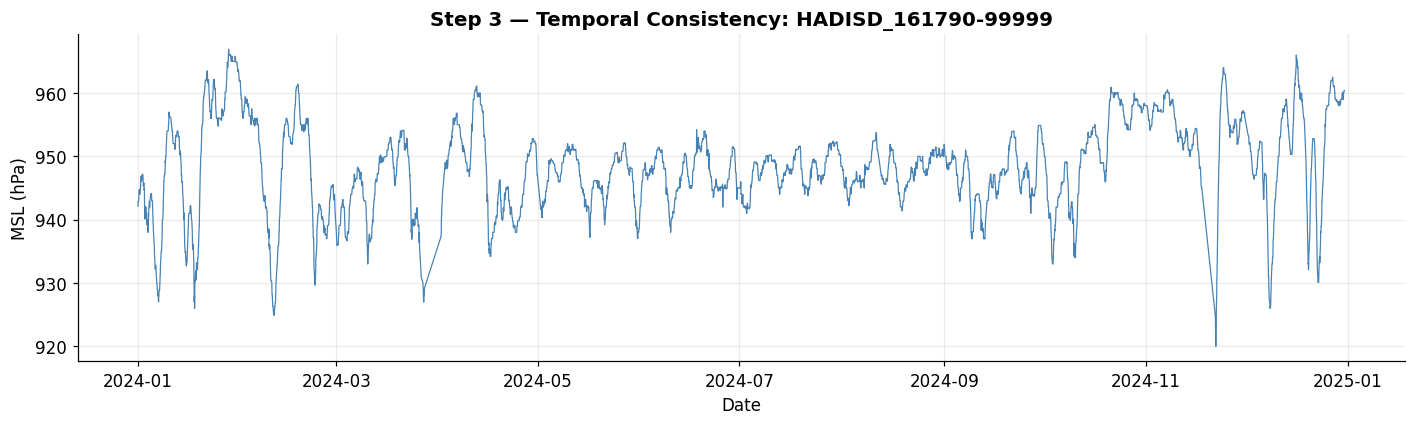

In [12]:
def detect_jumps(df, threshold_hpa=10.0):
    """Flag consecutive-hour jumps exceeding threshold_hpa."""
    results = []
    for sid, grp in df.groupby('station_id'):
        grp = grp.sort_values('dt')
        diff = grp['value'].diff().abs()
        # Only flag jumps between consecutive hours
        dt_diff = grp['dt'].diff().dt.total_seconds() / 3600
        consec = (dt_diff <= 1.5)  # within 1.5h window
        n_jumps = ((diff > threshold_hpa) & consec).sum()
        results.append({'station_id': sid, 'n_jumps': n_jumps,
                        'max_jump': diff[consec].max() if consec.any() else 0})
    return pd.DataFrame(results)

jump_df = detect_jumps(hadisd, threshold_hpa=JUMP_THRESHOLD)
station_qc['n_jumps'] = jump_df.set_index('station_id')['n_jumps'].values
station_qc['flagged_jumps'] = station_qc['n_jumps'] > 0

print(f'Stations with temporal jumps > {JUMP_THRESHOLD} hPa: {station_qc["flagged_jumps"].sum()}')
print(jump_df[jump_df['n_jumps']>0].to_string(index=False))

# Plot time series of a station with most obs as sanity check
best_station = hadisd.groupby('station_id').size().idxmax()
ts = hadisd[hadisd['station_id']==best_station].sort_values('dt')
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(ts['dt'], ts['value'], linewidth=0.8, color='steelblue')
ax.set(xlabel='Date', ylabel='MSL (hPa)',
       title=f'Step 3 — Temporal Consistency: {best_station}')
plt.tight_layout(); plt.savefig('s3_temporal.png', bbox_inches='tight'); plt.show()

## 3.4 QC Summary — Flag and Report

In [13]:
station_qc['flagged_any'] = (
    station_qc['flagged_missing'] | station_qc['flagged_jumps']
)
print('='*55)
print('  STEP 3 — QC SUMMARY')
print('='*55)
print(f'  Total stations     : {len(station_qc)}')
print(f'  Flagged (missing)  : {station_qc["flagged_missing"].sum()}')
print(f'  Flagged (jumps)    : {station_qc["flagged_jumps"].sum()}')
print(f'  Flagged (any)      : {station_qc["flagged_any"].sum()}')
print(f'  Clean stations     : {(~station_qc["flagged_any"]).sum()}')
print('='*55)
print(station_qc.to_string())

station_qc.to_csv('hadisd_station_qc.csv', index=True)
print('\nSaved -> hadisd_station_qc.csv')

  STEP 3 — QC SUMMARY
  Total stations     : 128
  Flagged (missing)  : 6
  Flagged (jumps)    : 11
  Flagged (any)      : 17
  Clean stations     : 111
                     n_obs  missing_pct  flagged_missing  n_phys_outliers  n_jumps  flagged_jumps  flagged_any
station_id                                                                                                    
HADISD_129250-99999   2411    16.284722            False                0        0          False        False
HADISD_129300-99999   2079    27.812500            False                0        0          False        False
HADISD_129420-99999   2200    23.611111            False                0        0          False        False
HADISD_129600-99999   2195    23.784722            False                0        0          False        False
HADISD_130145-99999     32    98.888889             True                0        0          False         True
HADISD_130260-99999   6466     0.000000            False              

---
# STEP 4 — Coverage Assessment

Characterises the spatial distribution of HadISD stations over the domain,
their variable availability, and the zones of the ERA5 grid not covered by any station.

## 4.1 Station Map — HadISD vs ERA5 Grid

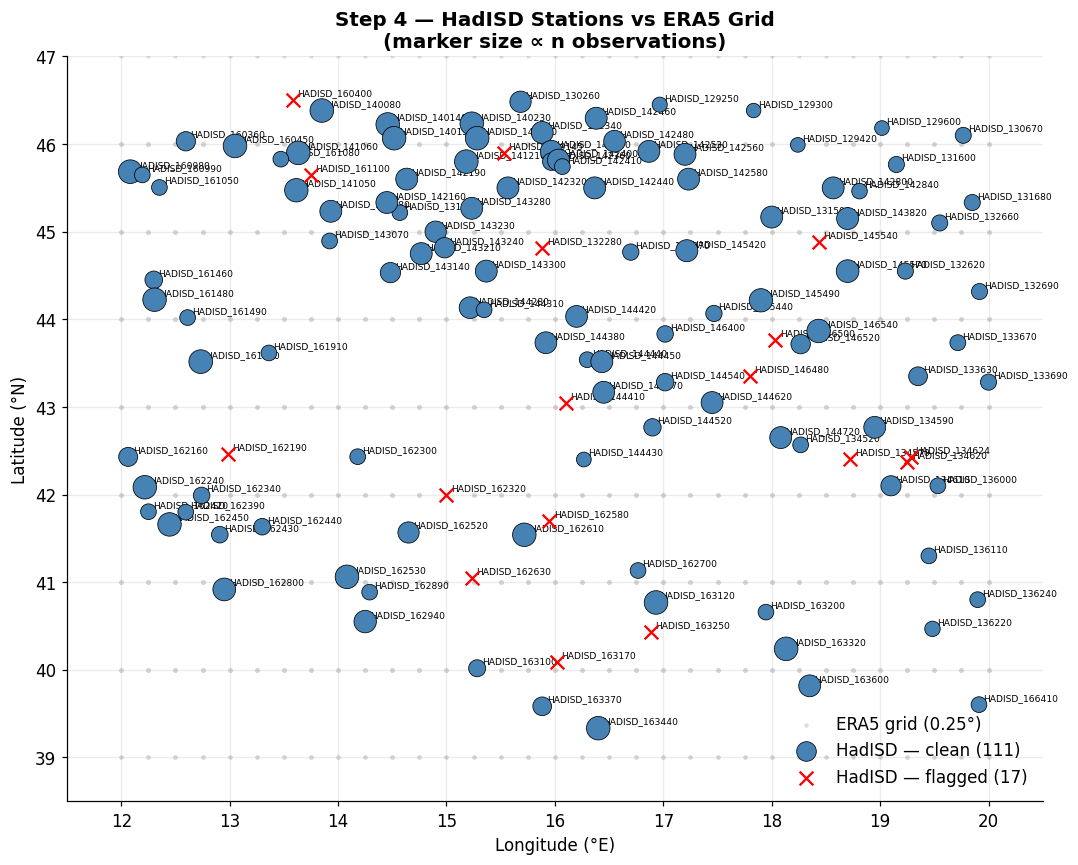

In [14]:
# ERA5 grid points from first available month
era5_sample = list(era5.values())[0]

fig, ax = plt.subplots(figsize=(10, 8))

# ERA5 grid (background)
ax.scatter(era5_sample['lon'], era5_sample['lat'],
           s=4, color='lightgray', alpha=0.6, label='ERA5 grid (0.25°)', zorder=1)

# HadISD stations coloured by QC status
sta_info = hadisd.groupby(['station_id','lat','lon']).size().reset_index(name='n_obs')
sta_info = sta_info.merge(
    station_qc[['flagged_any']].reset_index(), on='station_id', how='left'
)
clean = sta_info[~sta_info['flagged_any'].fillna(False)]
flagged = sta_info[sta_info['flagged_any'].fillna(False)]

ax.scatter(clean['lon'], clean['lat'],
           s=clean['n_obs']/clean['n_obs'].max()*200+40,
           color='steelblue', edgecolors='black', linewidths=0.5,
           zorder=5, label=f'HadISD — clean ({len(clean)})')
if len(flagged):
    ax.scatter(flagged['lon'], flagged['lat'],
               s=80, color='red', marker='x', linewidths=1.5,
               zorder=6, label=f'HadISD — flagged ({len(flagged)})')

# Annotate station IDs
for _, row in sta_info.iterrows():
    ax.annotate(row['station_id'].split('-')[0],
                (row['lon'], row['lat']), fontsize=6,
                xytext=(3, 3), textcoords='offset points', color='black')

ax.set(xlim=(LON_MIN-0.5, LON_MAX+0.5), ylim=(LAT_MIN-0.5, LAT_MAX+0.5),
       xlabel='Longitude (°E)', ylabel='Latitude (°N)',
       title='Step 4 — HadISD Stations vs ERA5 Grid\n(marker size ∝ n observations)')
ax.legend(loc='lower right')
plt.tight_layout(); plt.savefig('s4_station_map.png', bbox_inches='tight'); plt.show()

## 4.2 Variable Availability per Station

In [15]:
# Load ALL sensor codes to check variable availability across stations
def load_hadisd_all_vars(folder):
    files = sorted(glob.glob(os.path.join(folder, '*.csv')))
    dfs = []
    for f in files:
        try: dfs.append(pd.read_csv(f))
        except: pass
    if not dfs: return pd.DataFrame()
    df = pd.concat(dfs, ignore_index=True)
    df = df[df['lat'].between(LAT_MIN,LAT_MAX) & df['lon'].between(LON_MIN,LON_MAX)]
    return df

df_all = load_hadisd_all_vars(HADISD_DIR)

if 'sensor_code' in df_all.columns and len(df_all)>0:
    avail = df_all.groupby(['station_id','sensor_code']).size().unstack(fill_value=0)
    avail_bool = (avail > 0).astype(int)
    print('Variable availability per station:')
    print(avail_bool.to_string())

    fig, ax = plt.subplots(figsize=(max(6,len(avail_bool.columns)+2),
                                    max(4,len(avail_bool)*0.4+2)))
    im = ax.imshow(avail_bool.values, cmap='Blues', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(avail_bool.columns)))
    ax.set_xticklabels(avail_bool.columns, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(avail_bool.index)))
    ax.set_yticklabels([s[:18] for s in avail_bool.index], fontsize=8)
    for i in range(len(avail_bool.index)):
        for j in range(len(avail_bool.columns)):
            ax.text(j, i, '✓' if avail_bool.values[i,j] else '✗',
                    ha='center', va='center', fontsize=9,
                    color='white' if avail_bool.values[i,j] else 'lightgray')
    ax.set_title('Step 4 — Variable Availability per Station')
    plt.tight_layout(); plt.savefig('s4_variable_availability.png', bbox_inches='tight'); plt.show()
else:
    print('sensor_code column not available — skipping variable availability heatmap.')

sensor_code column not available — skipping variable availability heatmap.


## 4.3 Uncovered ERA5 Grid Cells

ERA5 grid points total           : 1024
Covered (within 150 km)       : 1005
Uncovered (> 150 km)          : 18
Mean distance to nearest station : nan km
Max distance to nearest station  : nan km


ValueError: x and y must be the same size

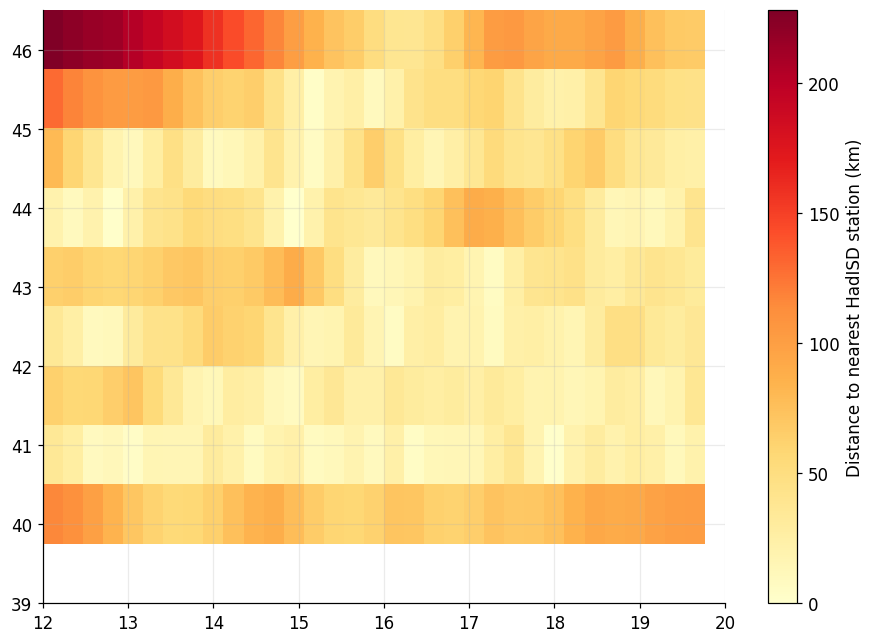

In [16]:
# For each ERA5 grid point, find distance to nearest HadISD station
sta_coords = hadisd[['lat','lon']].drop_duplicates().values
era5_pts   = np.column_stack([era5_sample['lat'], era5_sample['lon']])

def min_distance_km(era5_pts, sta_coords):
    """Approximate great-circle distance in km (flat-earth for small domain)."""
    dists = []
    for ep in era5_pts:
        d = np.sqrt(((sta_coords[:,0]-ep[0])*111)**2 +
                    ((sta_coords[:,1]-ep[1])*111*np.cos(np.radians(ep[0])))**2)
        dists.append(d.min())
    return np.array(dists)

min_dist = min_distance_km(era5_pts, sta_coords)
threshold_km = 150  # consider uncovered if no station within 150 km

print(f'ERA5 grid points total           : {len(era5_pts)}')
print(f'Covered (within {threshold_km} km)       : {(min_dist<=threshold_km).sum()}')
print(f'Uncovered (> {threshold_km} km)          : {(min_dist>threshold_km).sum()}')
print(f'Mean distance to nearest station : {min_dist.mean():.1f} km')
print(f'Max distance to nearest station  : {min_dist.max():.1f} km')

# Map
def to_grid_vec(vals, lon, lat, lats_u, lons_u):
    g = np.full((len(lats_u), len(lons_u)), np.nan)
    li={v:i for i,v in enumerate(lons_u)}; la={v:i for i,v in enumerate(lats_u)}
    for v,lo,lt in zip(vals,lon,lat):
        if not (np.isnan(lo) or np.isnan(lt)): g[la[lt],li[lo]] = v
    return g

dist_grid = to_grid_vec(min_dist, era5_sample['lon'], era5_sample['lat'],
                        era5_sample['lats_uniq'], era5_sample['lons_uniq'])

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(dist_grid, cmap='YlOrRd',
               extent=[LON_MIN,LON_MAX,LAT_MIN,LAT_MAX], aspect='auto')
plt.colorbar(im, ax=ax, label='Distance to nearest HadISD station (km)')
ax.scatter(hadisd['lon'].unique(), hadisd['lat'].unique(),
           s=60, color='blue', edgecolors='black', linewidths=0.5,
           zorder=5, label='HadISD stations')
ax.contour(dist_grid, levels=[threshold_km], colors='red', linewidths=1.5,
           extent=[LON_MIN,LON_MAX,LAT_MAX,LAT_MIN])
ax.set(xlim=(LON_MIN,LON_MAX), ylim=(LAT_MIN,LAT_MAX),
       xlabel='Lon (°E)', ylabel='Lat (°N)',
       title=f'Step 4 — ERA5 Grid Coverage\n(red contour = {threshold_km} km threshold)')
ax.legend()
plt.tight_layout(); plt.savefig('s4_coverage_map.png', bbox_inches='tight'); plt.show()

---
# Final Report Summary

In [ ]:
print('='*60)
print('  FULL PIPELINE SUMMARY')
print('='*60)
print(f'  STEP 1 — Alignment')
print(f'    Co-location pairs        : {len(coloc)}')
print(f'    Unique stations matched  : {coloc["station_id"].nunique()}')
print(f'    Overall mean bias (hPa)  : {coloc["bias"].mean():+.3f}')
print(f'    Overall RMSE  (hPa)      : {np.sqrt((coloc["bias"]**2).mean()):.3f}')
print()
print(f'  STEP 2 — Seasonal bias')
for s, grp in coloc.groupby('season'):
    print(f'    {s:7s}: mean={grp["bias"].mean():+.3f}  std={grp["bias"].std():.3f} hPa')
print()
print(f'  STEP 3 — HadISD quality')
print(f'    Total stations           : {len(station_qc)}')
print(f'    Flagged stations         : {station_qc["flagged_any"].sum()}')
print(f'    Clean stations           : {(~station_qc["flagged_any"]).sum()}')
print()
print(f'  STEP 4 — Coverage')
print(f'    ERA5 grid points         : {len(era5_pts)}')
print(f'    Mean dist to station (km): {min_dist.mean():.1f}')
print(f'    Uncovered pts (>{threshold_km}km)  : {(min_dist>threshold_km).sum()}')
print()
print('  Saved files:')
for f in ['colocation_era5_hadisd_msl.csv','hadisd_station_qc.csv',
          's1_scatter.png','s2_bias_boxplot.png','s2_spatial_bias.png',
          's2_bias_heatmap.png','s3_missing_rate.png','s3_distribution.png',
          's3_temporal.png','s4_station_map.png',
          's4_variable_availability.png','s4_coverage_map.png']:
    print(f'    {f}')
print('='*60)